# 03B – Model Evaluation (Enterprise)

This notebook evaluates the production bankruptcy prediction model trained on **american_bankruptcy_cleaned.csv**.

## Business Objective
Evaluate the production model using industry-standard classification metrics and visualizations.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'
MODEL_PATH='../models/production_bankruptcy_model.joblib'

df=pd.read_csv(DATA_PATH)

target='status_label' if 'status_label' in df.columns else 'target'

if target=='status_label':
    y=df[target].map({'alive':0,'failed':1})
else:
    y=df[target]

X=df.drop(columns=[target])
if 'company_name' in X.columns:
    X=X.drop(columns=['company_name'])

_,X_test,_,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model=joblib.load(MODEL_PATH)
pred=model.predict(X_test)
prob=model.predict_proba(X_test)[:,1]

In [3]:
metrics=pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
    'Value':[
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ]
})

metrics.to_csv('evaluation_metrics.csv',index=False)
metrics

,Metric,Value
0,Accuracy,0.937409
1,Precision,1.000000
2,Recall,0.056513
3,F1 Score,0.106981
4,ROC-AUC,0.901921


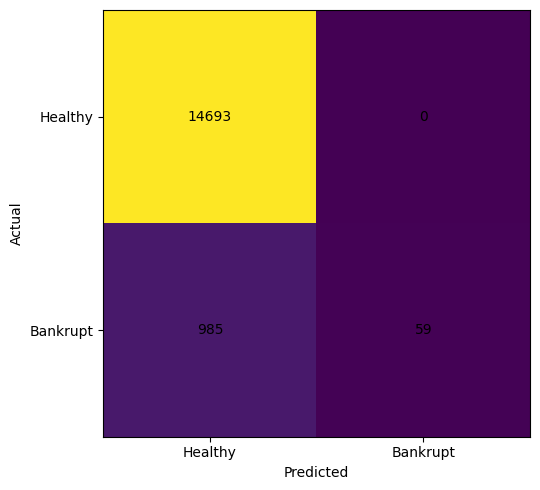

In [4]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.xticks([0,1],['Healthy','Bankrupt'])
plt.yticks([0,1],['Healthy','Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')

plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=300)
plt.show()

report=pd.DataFrame(classification_report(y_test,pred,output_dict=True)).T
report.to_csv('classification_report.csv')

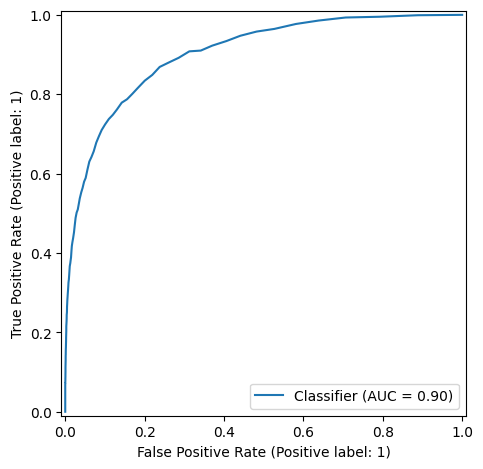

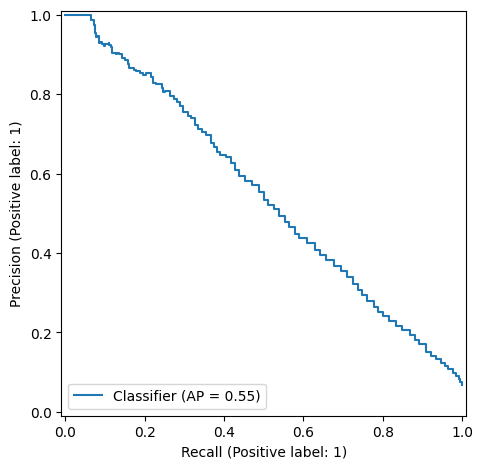

In [5]:
RocCurveDisplay.from_predictions(y_test,prob)
plt.tight_layout()
plt.savefig('roc_curve.png',dpi=300)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test,prob)
plt.tight_layout()
plt.savefig('precision_recall_curve.png',dpi=300)
plt.show()

## Deliverables

- `evaluation_metrics.csv`
- `classification_report.csv`
- `confusion_matrix.png`
- `roc_curve.png`
- `precision_recall_curve.png`

These evaluation artifacts are used to assess the production model before explainability and validation.

## Executive Summary

The production model has been evaluated using standard classification metrics, ROC analysis, Precision–Recall analysis, and a confusion matrix to verify predictive performance before downstream explainability and validation.